In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab_dataset/kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.shape

(400, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [6]:
# drop id column
df.drop(columns=['id'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [8]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [9]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [10]:
df.dtypes

,0
age,float64
blood_pressure,float64
specific_gravity,float64
albumin,float64
sugar,float64
red_blood_cells,object
pus_cell,object
pus_cell_clumps,object
bacteria,object
blood_glucose_random,float64


In [11]:
df['packed_cell_volume'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [12]:
# due to substring column it is object
# but want to convert into numeric
df['packed_cell_volume']=pd.to_numeric(df['packed_cell_volume'], errors="coerce" ) # coerce mean javarjasti error resolve karke the error ad subpress the error s
df['packed_cell_volume']

,packed_cell_volume
0,44.0
1,38.0
2,31.0
3,32.0
4,35.0
...,...
395,47.0
396,54.0
397,49.0
398,51.0


In [13]:
df['packed_cell_volume'].unique()

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [14]:
df['white_blood_cell_count'].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '\t6200', '7100', '11800', '9400', '5500', '5800',
       '13200', '12500', '5600', '7000', '11900', '10400', '10700',
       '12700', '6800', '6500', '13600', '10200', '9000', '14900', '8200',
       '15200', '5000', '16300', '12400', '\t8400', '10500', '4200',
       '4700', '10900', '8100', '9500', '2200', '12800', '11200', '19100',
       '\t?', '12300', '16700', '2600', '26400', '8800', '7400', '4900',
       '8000', '12000', '15700', '4100', '5700', '11500', '5400', '10800',
       '9900', '5200', '5900', '9300', '9700', '5100', '6600'],
      dtype=object)

In [15]:
df['white_blood_cell_count']=pd.to_numeric(df['white_blood_cell_count'],errors='coerce')#

In [16]:
df['white_blood_cell_count'].unique()

array([ 7800.,  6000.,  7500.,  6700.,  7300.,    nan,  6900.,  9600.,
       12100.,  4500., 12200., 11000.,  3800., 11400.,  5300.,  9200.,
        6200.,  8300.,  8400., 10300.,  9800.,  9100.,  7900.,  6400.,
        8600., 18900., 21600.,  4300.,  8500., 11300.,  7200.,  7700.,
       14600.,  6300.,  7100., 11800.,  9400.,  5500.,  5800., 13200.,
       12500.,  5600.,  7000., 11900., 10400., 10700., 12700.,  6800.,
        6500., 13600., 10200.,  9000., 14900.,  8200., 15200.,  5000.,
       16300., 12400., 10500.,  4200.,  4700., 10900.,  8100.,  9500.,
        2200., 12800., 11200., 19100., 12300., 16700.,  2600., 26400.,
        8800.,  7400.,  4900.,  8000., 12000., 15700.,  4100.,  5700.,
       11500.,  5400., 10800.,  9900.,  5200.,  5900.,  9300.,  9700.,
        5100.,  6600.])

In [17]:
df['red_blood_cell_count'].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4.0', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6.0', '5.0', '2.1', '5.6', '2.3',
       '2.9', '2.7', '8.0', '3.3', '3.0', '3', '2.4', '4.8', '\t?', '5.4',
       '6.1', '6.2', '6.3', '5.1', '5.8', '5.5', '5.3', '6.4', '5.7',
       '5.9', '6.5'], dtype=object)

In [18]:
df['red_blood_cell_count']=pd.to_numeric(df['red_blood_cell_count'],errors='coerce')

In [19]:
df['red_blood_cell_count'].unique()

array([5.2, nan, 3.9, 4.6, 4.4, 5. , 4. , 3.7, 3.8, 3.4, 2.6, 2.8, 4.3,
       3.2, 3.6, 4.1, 4.9, 2.5, 4.2, 4.5, 3.1, 4.7, 3.5, 6. , 2.1, 5.6,
       2.3, 2.9, 2.7, 8. , 3.3, 3. , 2.4, 4.8, 5.4, 6.1, 6.2, 6.3, 5.1,
       5.8, 5.5, 5.3, 6.4, 5.7, 5.9, 6.5])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [21]:
cat_cols=[ col for col in df.columns if df[col].dtypes== 'object']

In [22]:
num_cols=[ col for col in df.columns if df[col].dtypes!= 'object']

In [23]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [24]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [25]:
for col in cat_cols:
  print(f"{col} has {df[col].unique()} unique values\n")

red_blood_cells has [nan 'normal' 'abnormal'] unique values

pus_cell has ['normal' 'abnormal' nan] unique values

pus_cell_clumps has ['notpresent' 'present' nan] unique values

bacteria has ['notpresent' 'present' nan] unique values

hypertension has ['yes' 'no' nan] unique values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] unique values

coronary_artery_disease has ['no' 'yes' '\tno' nan] unique values

appetite has ['good' 'poor' nan] unique values

peda_edema has ['no' 'yes' nan] unique values

aanemia has ['no' 'yes' nan] unique values

class has ['ckd' 'ckd\t' 'notckd'] unique values



In [26]:
df['diabetes_mellitus'].value_counts()

,count
diabetes_mellitus,
no,258
yes,134
\tno,3
\tyes,2
yes,1


In [27]:
df['diabetes_mellitus'].replace(to_replace={' yes':'yes','\tyes':'yes','\tno': 'no'},inplace=True)

In [28]:
df['diabetes_mellitus'].value_counts()

,count
diabetes_mellitus,
no,261
yes,137


In [29]:
df['coronary_artery_disease'].value_counts()

,count
coronary_artery_disease,
no,362
yes,34
\tno,2


In [30]:
df['coronary_artery_disease'].replace("\tno","no",inplace=True)

In [31]:
df['coronary_artery_disease'].value_counts()

,count
coronary_artery_disease,
no,364
yes,34


In [32]:
df['class'].value_counts()

,count
class,
ckd,248
notckd,150
ckd\t,2


In [33]:
df['class']=df['class'].map({'ckd':1,'notckd':0, 'cdk\t':1})

In [34]:
df['class'].value_counts()

,count
class,
1.0,248
0.0,150


In [35]:
df['class'].unique()

array([ 1., nan,  0.])

# Univarient analysis

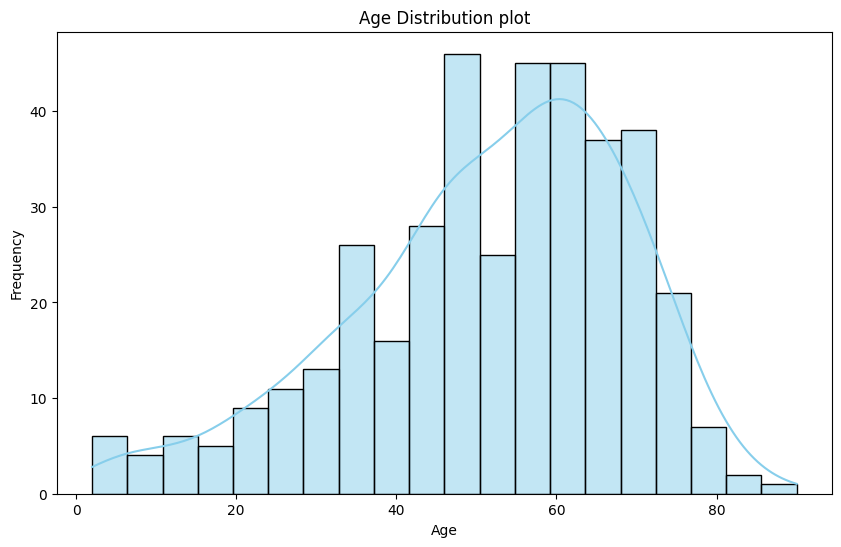

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(), kde=True, bins=20, color='skyblue')
plt.title("Age Distribution plot")
plt.xlabel('Age')
plt.ylabel("Frequency")
plt.show()

In [37]:
#Insides>>  Age column have left skewed data

In [38]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='hypertension', ylabel='count'>

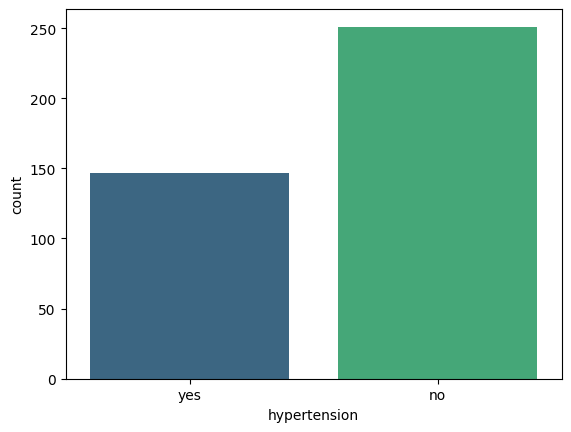

In [39]:
sns.countplot(x='hypertension',data=df, palette='viridis')

In [40]:
# Inside >> 150 have hypertension out of 400

<Axes: xlabel='class', ylabel='blood_urea'>

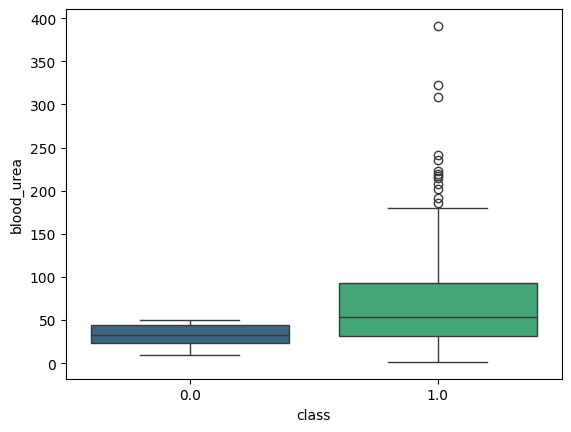

In [41]:
sns.boxplot(x='class',y='blood_urea', data=df,palette='viridis')

In [42]:
# Insides>> people with kidney desiase has higher blood urea with outliers and median is so high

<Axes: xlabel='class', ylabel='serum_creatinine'>

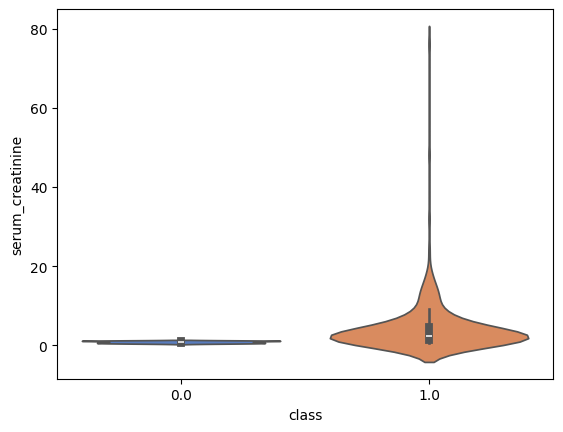

In [43]:
sns.violinplot(x='class', y='serum_creatinine', data=df, palette='muted')

In [44]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='aanemia', ylabel='count'>

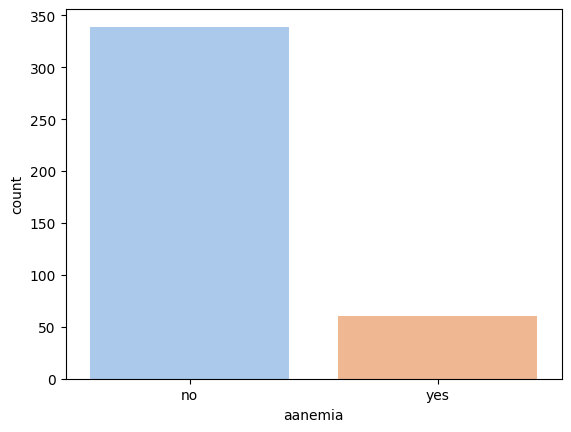

In [45]:
sns.countplot(x='aanemia', data=df, palette='pastel')

In [46]:
# Insides >> majority of people are not sufereing from anemia

<Axes: ylabel='count'>

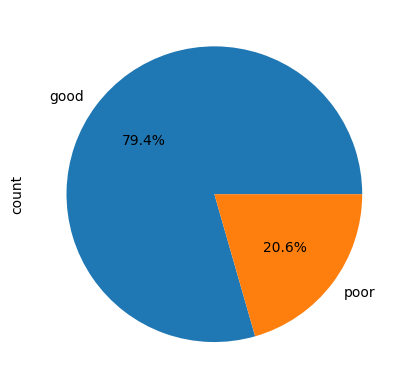

In [47]:
df['appetite'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

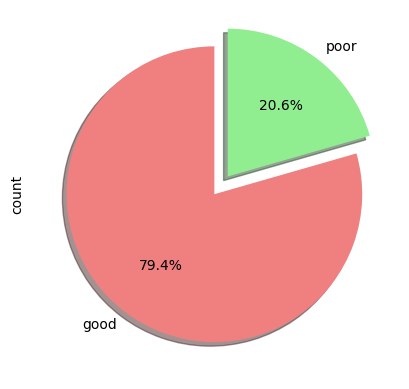

In [48]:
df['appetite'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,colors=["lightcoral",'lightgreen'],explode=(0,0.15,),shadow=True)

In [49]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [50]:
df.pus_cell_clumps.unique()

array(['notpresent', 'present', nan], dtype=object)

<Axes: xlabel='pus_cell_clumps', ylabel='count'>

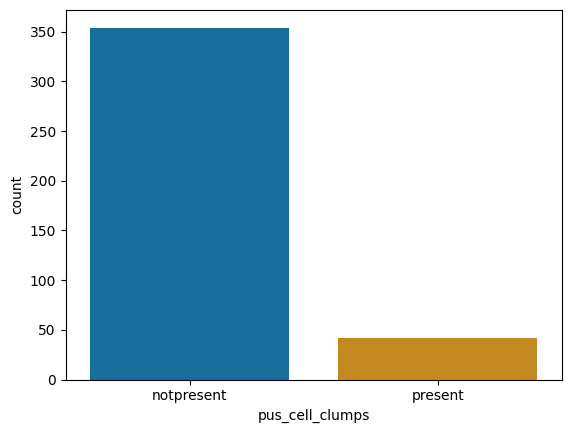

In [51]:
sns.countplot(x='pus_cell_clumps',data=df,palette='colorblind')

In [52]:
# Insides >> majory

In [53]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='white_blood_cell_count', ylabel='Count'>

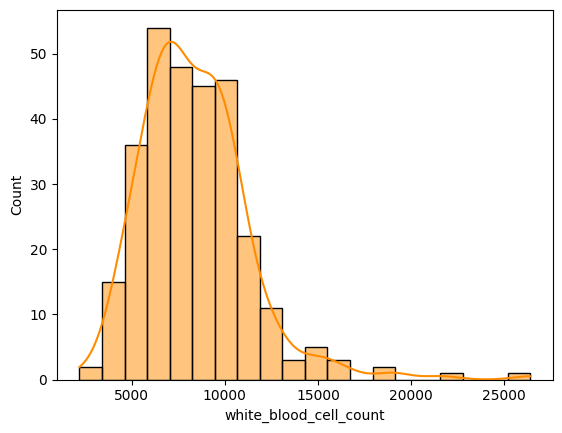

In [54]:
sns.histplot(df['white_blood_cell_count'].dropna(),bins=20, kde=True,color='darkorange')

In [55]:
# Donat or ring chart a type of pie chart
# it used to display propotion

<Axes: ylabel='count'>

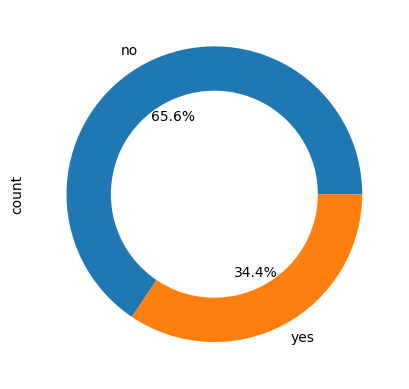

In [56]:
df['diabetes_mellitus'].value_counts().plot.pie(autopct='%1.1f%%', wedgeprops=dict(width=0.3))

<Axes: xlabel='coronary_artery_disease', ylabel='count'>

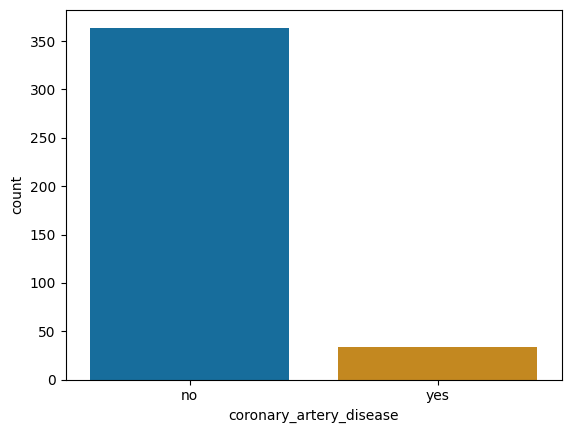

In [57]:
sns.countplot(x='coronary_artery_disease',data=df, palette='colorblind')

<Axes: xlabel='peda_edema', ylabel='count'>

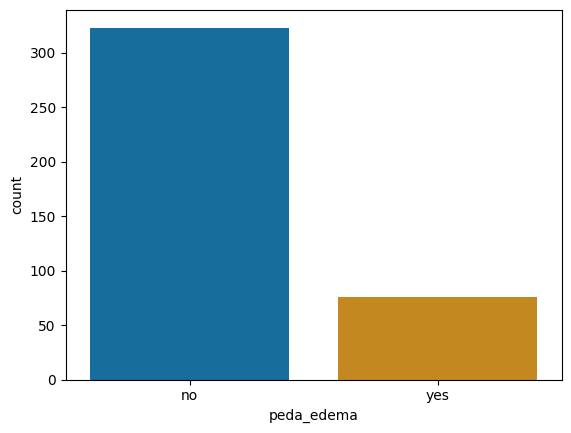

In [58]:
sns.countplot(x='peda_edema',data=df,palette='colorblind')

<Axes: xlabel='bacteria', ylabel='count'>

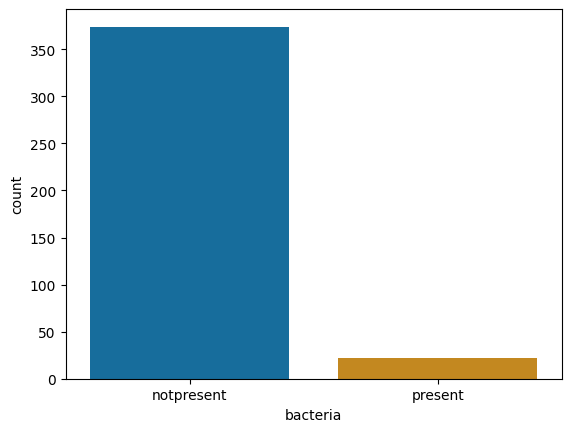

In [59]:
sns.countplot(x='bacteria',data=df,palette='colorblind')

# Bivarient analysis

In [60]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='age', ylabel='blood_pressure'>

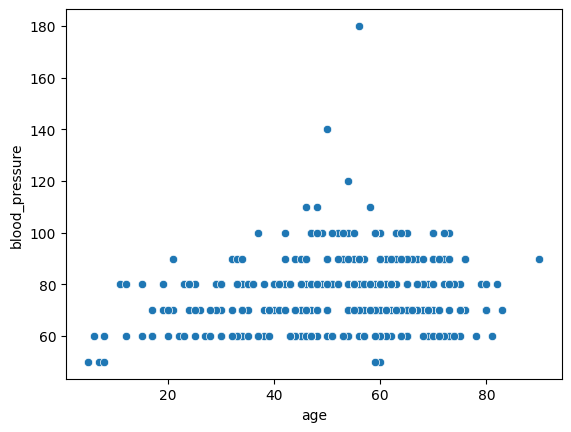

In [61]:
sns.scatterplot(x='age',y='blood_pressure',data=df)

<Axes: xlabel='age', ylabel='blood_pressure'>

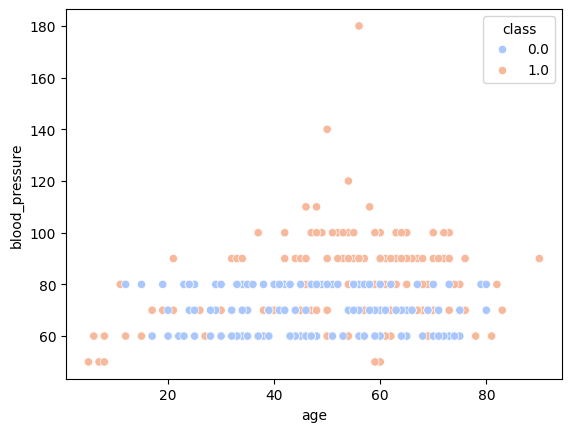

In [62]:
# Insides>> As age is increasing blood pressure are increasing
sns.scatterplot(x='age',y='blood_pressure',data=df, hue='class',palette='coolwarm')

In [63]:
# Insides>> majority kidney desiase patient has high bp problem

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

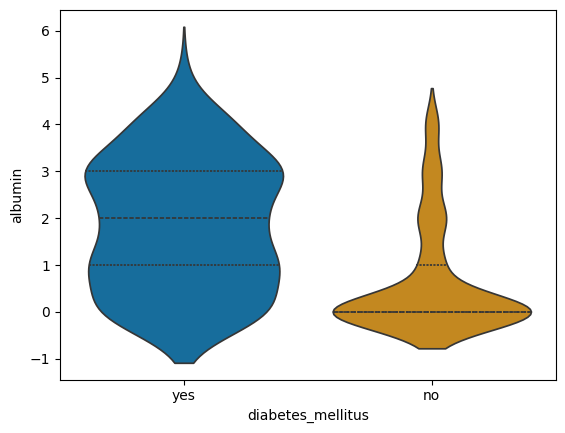

In [64]:
sns.violinplot(x='diabetes_mellitus', y='albumin', data=df,palette='colorblind',inner='quart')

In [65]:
# Stacked bar chart
# analyse dibetease_matelous and hypertension
pd.crosstab(df['diabetes_mellitus'],df['hypertension']) # summarize the data


hypertension,no,yes
diabetes_mellitus,,
no,220,41
yes,31,106


In [66]:
dibetease_hypertension=pd.crosstab(df['diabetes_mellitus'],df['hypertension'])

<Axes: xlabel='diabetes_mellitus'>

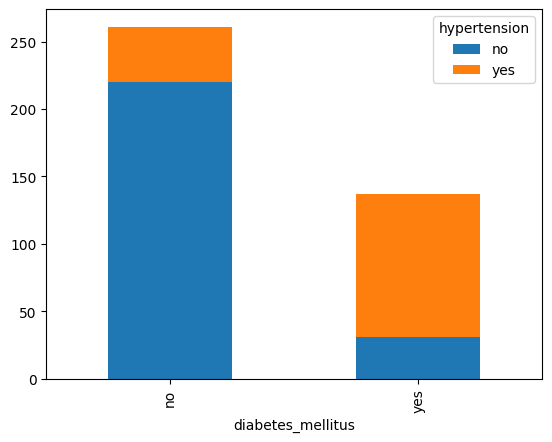

In [67]:
dibetease_hypertension.plot(kind='bar',stacked=True)

In [68]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

# multivarient analysis

In [69]:
# Multivarient analysis
cols=['age' ,'blood_pressure','blood_glucose_random','serum_creatinine','class']

In [70]:
df[cols]

,age,blood_pressure,blood_glucose_random,serum_creatinine,class
0,48.0,80.0,121.0,1.2,1.0
1,7.0,50.0,NaN,0.8,1.0
2,62.0,80.0,423.0,1.8,1.0
3,48.0,70.0,117.0,3.8,1.0
4,51.0,80.0,106.0,1.4,1.0
...,...,...,...,...,...
395,55.0,80.0,140.0,0.5,0.0
396,42.0,70.0,75.0,1.2,0.0
397,12.0,80.0,100.0,0.6,0.0
398,17.0,60.0,114.0,1.0,0.0


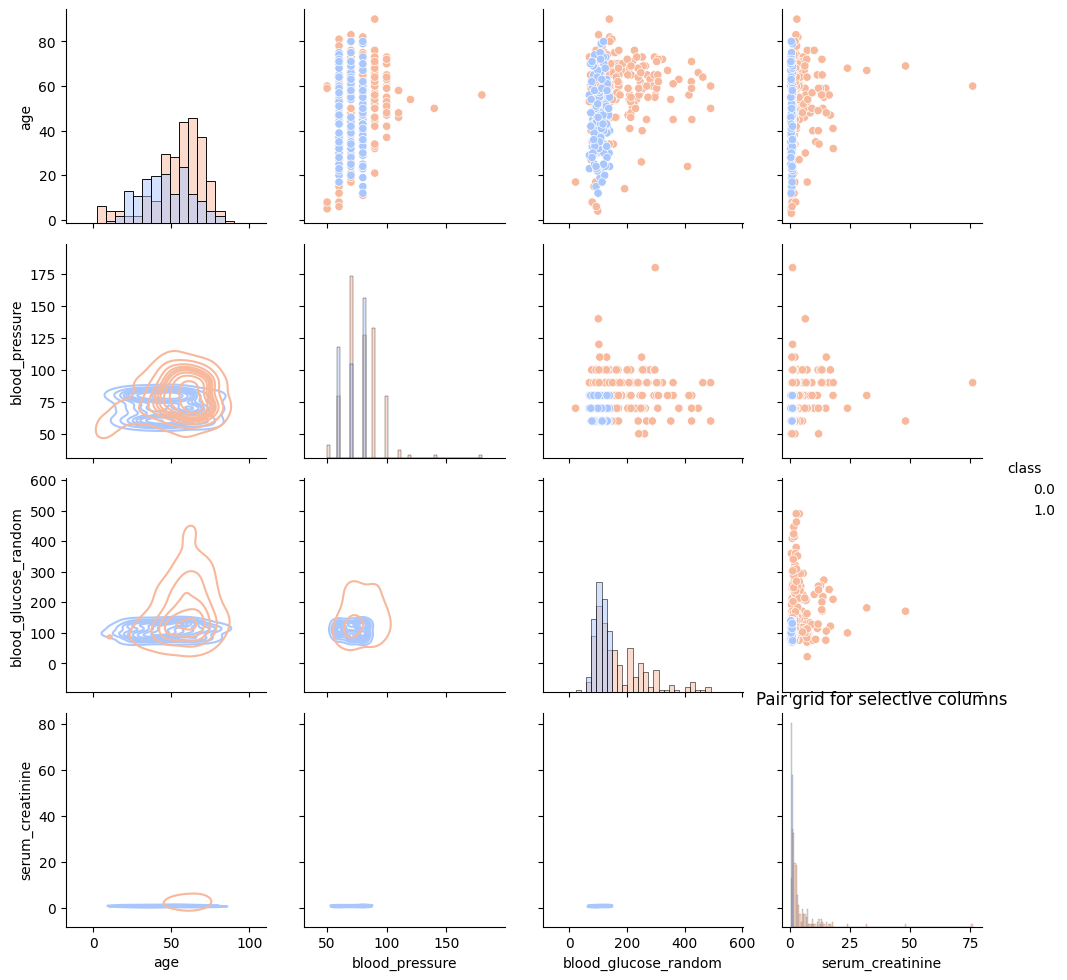

In [71]:
#custumize pairplot
g=sns.PairGrid(df[cols], hue='class',palette='coolwarm')
plt.title("Pair grid for selective columns")
g.add_legend()
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot, cmap='Blue_d')
g.map_diag(sns.histplot)


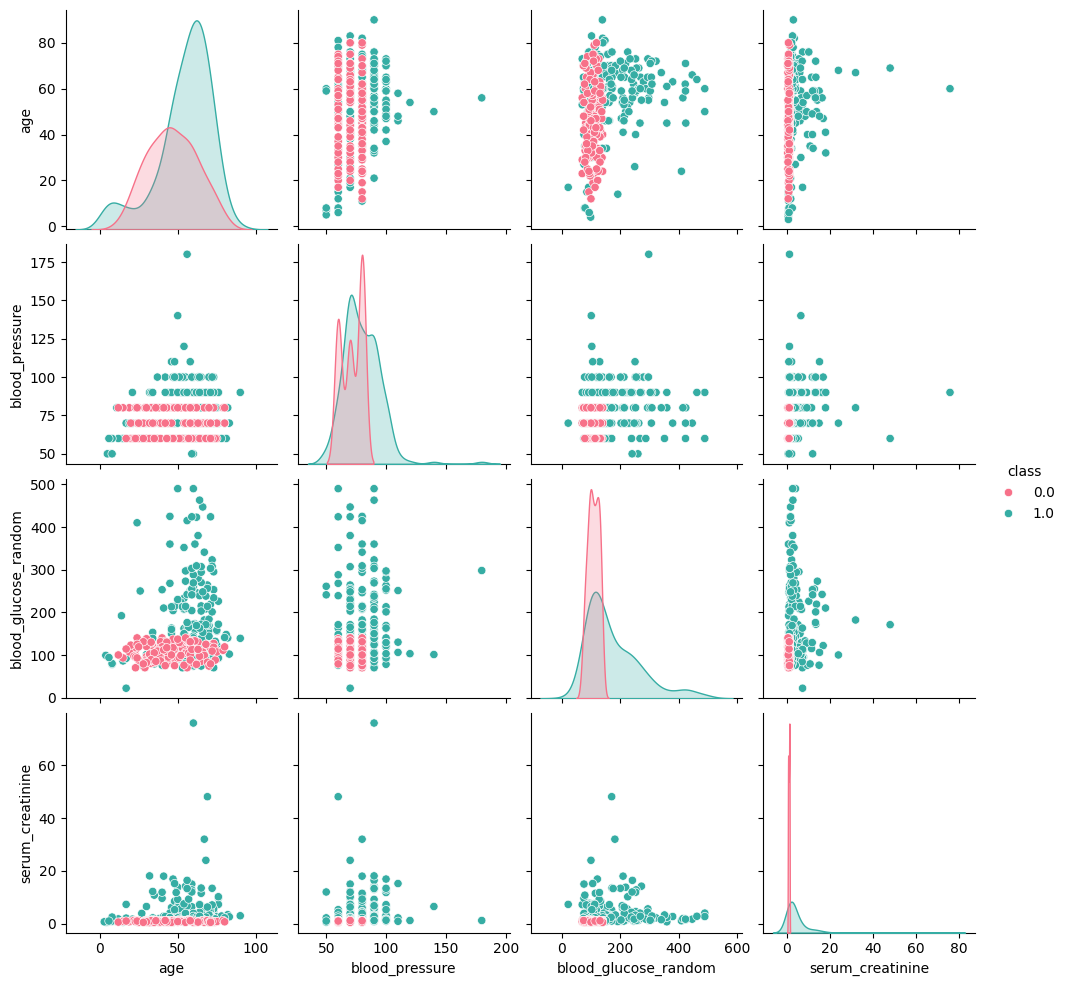

In [72]:
sns.pairplot(df[cols], hue='class', palette='husl')

In [73]:
df.corr(numeric_only=True)

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,class
age,1.000000,0.159480,-0.191096,0.122091,0.220866,0.244992,0.196985,0.132531,-0.100046,0.058377,-0.192928,-0.242119,0.118339,-0.268896,0.224211
blood_pressure,0.159480,1.000000,-0.218836,0.160689,0.222576,0.160193,0.188517,0.146222,-0.116422,0.075151,-0.306540,-0.326319,0.029753,-0.261936,0.297060
specific_gravity,-0.191096,-0.218836,1.000000,-0.469760,-0.296234,-0.374710,-0.314295,-0.361473,0.412190,-0.072787,0.602582,0.603560,-0.236215,0.579476,-0.731560
albumin,0.122091,0.160689,-0.469760,1.000000,0.269305,0.379464,0.453528,0.399198,-0.459896,0.129038,-0.634632,-0.611891,0.231989,-0.566437,0.626458
sugar,0.220866,0.222576,-0.296234,0.269305,1.000000,0.717827,0.168583,0.223244,-0.131776,0.219450,-0.224775,-0.239189,0.184893,-0.237448,0.345483
blood_glucose_random,0.244992,0.160193,-0.374710,0.379464,0.717827,1.000000,0.143322,0.114875,-0.267848,0.066966,-0.306189,-0.301385,0.150015,-0.281541,0.419703
blood_urea,0.196985,0.188517,-0.314295,0.453528,0.168583,0.143322,1.000000,0.586368,-0.323054,0.357049,-0.610360,-0.607621,0.050462,-0.579087,0.382893
serum_creatinine,0.132531,0.146222,-0.361473,0.399198,0.223244,0.114875,0.586368,1.000000,-0.690158,0.326107,-0.401670,-0.404193,-0.006390,-0.400852,0.300848
sodium,-0.100046,-0.116422,0.412190,-0.459896,-0.131776,-0.267848,-0.323054,-0.690158,1.000000,0.097887,0.365183,0.376914,0.007277,0.344873,-0.375934
potassium,0.058377,0.075151,-0.072787,0.129038,0.219450,0.066966,0.357049,0.326107,0.097887,1.000000,-0.133746,-0.163182,-0.105576,-0.158309,0.085021


<Axes: >

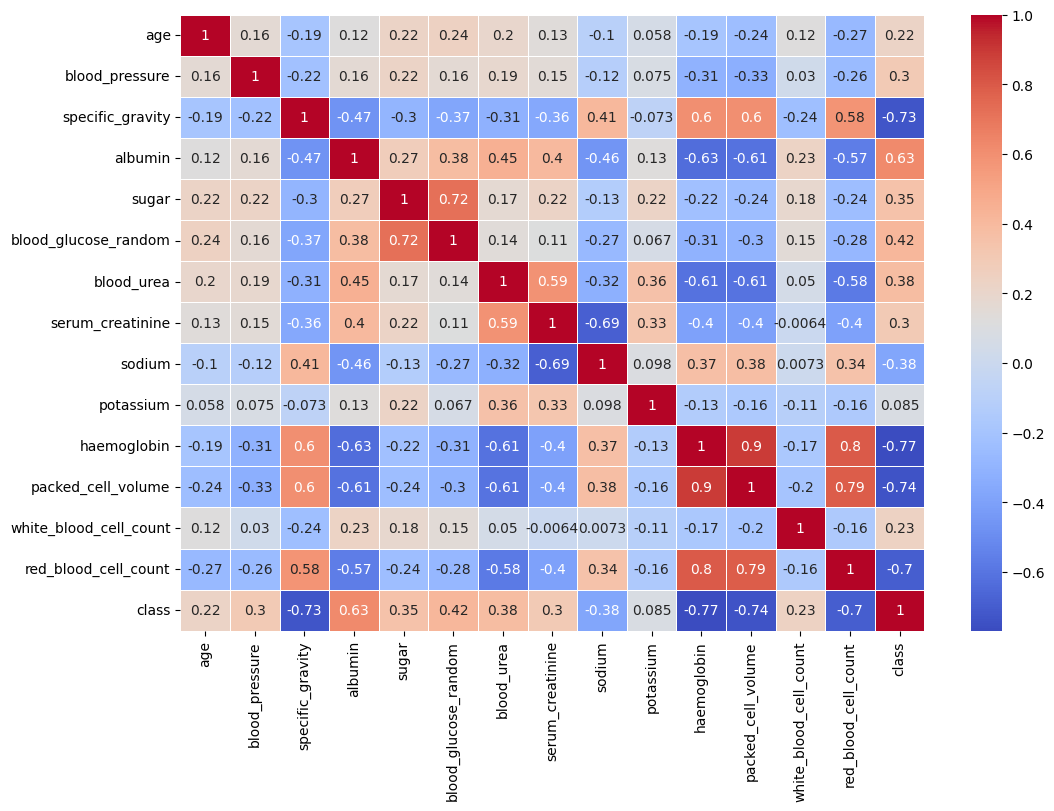

In [74]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

In [75]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='diabetes_mellitus', ylabel='age'>

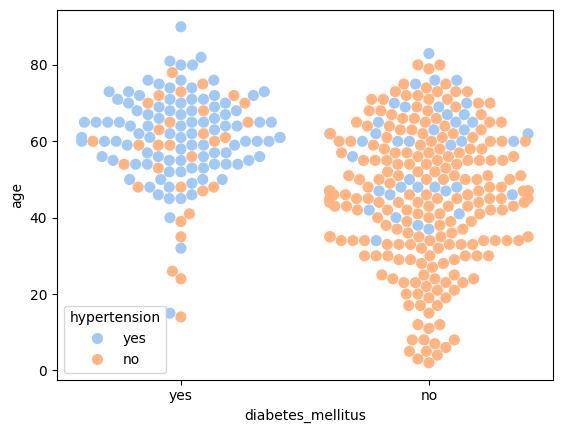

In [76]:
sns.swarmplot(x='diabetes_mellitus', y='age', hue='hypertension', data=df, palette='pastel', size=8)

In [77]:
# Swamplot allow you to see all the overlapping data as well
fig=px.scatter(df, x='age', y='blood_pressure', color='class' )
fig.show()

In [78]:
fig=px.scatter(df, x='age', y='blood_pressure', color='class', hover_data=[] )
fig.show()

In [79]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [82]:
fig=px.scatter(df, x='age', y='blood_pressure', color='class', hover_data=['serum_creatinine','haemoglobin'] ,title="Interachtive scatter plot with age , seram and hemoglobin")

In [83]:
fig.show()

In [84]:
# make the 3d plot
fig=px.scatter_3d(df,x='age', y='blood_pressure', z='serum_creatinine', color='class', title="3D scatter plot")
fig.show()

In [88]:
import plotly.graph_objects as go
corr= df.corr( numeric_only=True)
fig=go.Figure(data=go.Heatmap(z=corr.values, x=corr.columns, y=corr.index))
fig.show()

In [90]:
fig=px.scatter_3d(df,x='age', y='blood_pressure', z='serum_creatinine', color='haemoglobin', title="3D scatter plot")
fig.show()

In [91]:
df.isnull().sum()

,0
age,9
blood_pressure,12
specific_gravity,47
albumin,46
sugar,49
red_blood_cells,152
pus_cell,65
pus_cell_clumps,4
bacteria,4
blood_glucose_random,44


In [92]:
# Replace with median and mean for numerical column
median=df[num_cols].median()
median


,0
age,55.00
blood_pressure,80.00
specific_gravity,1.02
albumin,0.00
sugar,0.00
blood_glucose_random,121.00
blood_urea,42.00
serum_creatinine,1.30
sodium,138.00
potassium,4.40


In [93]:
df[num_cols]=df[num_cols].fillna(median)

In [95]:
df[num_cols].isnull().sum()

,0
age,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
blood_glucose_random,0
blood_urea,0
serum_creatinine,0
sodium,0
potassium,0


In [94]:
df.isnull().sum()

,0
age,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
red_blood_cells,152
pus_cell,65
pus_cell_clumps,4
bacteria,4
blood_glucose_random,0


In [96]:
mode_value=df[cat_cols].mode().iloc[0]
mode_value

,0
red_blood_cells,normal
pus_cell,normal
pus_cell_clumps,notpresent
bacteria,notpresent
hypertension,no
diabetes_mellitus,no
coronary_artery_disease,no
appetite,good
peda_edema,no
aanemia,no


In [97]:
df[cat_cols]=df[cat_cols].fillna(mode_value)

In [98]:
df.isnull().sum()

,0
age,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
red_blood_cells,0
pus_cell,0
pus_cell_clumps,0
bacteria,0
blood_glucose_random,0


In [99]:
df.dtypes

,0
age,float64
blood_pressure,float64
specific_gravity,float64
albumin,float64
sugar,float64
red_blood_cells,object
pus_cell,object
pus_cell_clumps,object
bacteria,object
blood_glucose_random,float64


In [100]:
# few collumns are object type convert it into numeric
from sklearn.preprocessing import LabelEncoder
lr=LabelEncoder()
for col in cat_cols:
  df[col]=lr.fit_transform(df[col])

In [101]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [103]:
df.dtypes

,0
age,float64
blood_pressure,float64
specific_gravity,float64
albumin,float64
sugar,float64
red_blood_cells,int64
pus_cell,int64
pus_cell_clumps,int64
bacteria,int64
blood_glucose_random,float64


In [104]:
X=df.drop('class',axis=1)
y=df['class']

In [ ]:
# Train test split and model trained